# Transit Route Generation Evaluation

This notebook evaluates two approaches for transit network design:
- **LC (Learning-based Construction)** – pure neural route generator
- **Neural BCO (Bee Colony Optimization with neural initialization)**

Tested on **Mandl's benchmark** and **Tartu real-world network**.

---

## 1. Setup & Configuration

In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import pickle
from pathlib import Path
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader
from tqdm import tqdm

# Project-specific imports
from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.torch_utils import dump_routes
from connectpt.routes_generator import bee_colony
import connectpt.routes_generator.utils as lrnu

In [2]:
!pip install h5py


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Root paths (adjust only here if needed)
ROOT_DIR = Path.cwd().parent.parent
DATA_DIR = ROOT_DIR / "examples/data"
CFG_DIR = ROOT_DIR / "connectpt/routes_generator/cfg"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples/data/model_weights/inductive_random_graphs_weighted_connectivity.pt"

# Verify paths
print("Root directory:", ROOT_DIR)
print("Config directory:", CFG_DIR)
print("Model weights exist:", MODEL_WEIGHTS_PATH.exists())

Root directory: d:\PythonProjects\connectpt
Config directory: d:\PythonProjects\connectpt\connectpt\routes_generator\cfg
Model weights exist: True


## 2. Load Benchmark Instances

### 2.1 Mandl's Benchmark (Classic 15-node instance)

In [4]:
def load_mandl_instance():
    data_dir = DATA_DIR / "benchmark"
    instance_name = "Mumford0"

    # Coordinates
    coords_path = data_dir / f"{instance_name}Coords.txt"
    node_locs = torch.tensor(np.genfromtxt(coords_path, skip_header=1), dtype=torch.float32)

    # Travel times (in seconds)
    tt_path = data_dir / f"{instance_name}TravelTimes.txt"
    street_adj = torch.tensor(np.genfromtxt(tt_path), dtype=torch.float32) * 60

    # Demand matrix
    dmd_path = data_dir / f"{instance_name}Demand.txt"
    demand = torch.tensor(np.genfromtxt(dmd_path), dtype=torch.float32)

    print(f"Mandl instance loaded:")
    print(f"  Nodes: {node_locs.shape[0]}, Demand shape: {demand.shape}")

    return {
        'street_adj': street_adj,
        'demand': demand,
        'node_locs': node_locs
    }

# Load Mandl
input_tensors_mandl = load_mandl_instance()

Mandl instance loaded:
  Nodes: 30, Demand shape: torch.Size([30, 30])


### 2.2 Tartu Real-World Network (199 nodes)

In [5]:
def load_tartu_instance():
    data_dir = DATA_DIR / "tartu"

    # Load graph
    with open(data_dir / "bus_graph_Tartu.pkl", "rb") as f:
        G = pickle.load(f)

    # Load demand (OD matrix)
    OD = pd.read_csv(data_dir / "OD_matrix_Tartu.csv", index_col=0)
    demand = torch.tensor(OD.values, dtype=torch.float32)

    # Sort nodes to match OD matrix order
    nodes = sorted(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Node coordinates
    node_locs = torch.tensor([[G.nodes[n]['x'], G.nodes[n]['y']] for n in nodes], dtype=torch.float32)

    # Build symmetric travel time matrix
    n = len(nodes)
    inf = float('inf')
    adj_matrix = np.full((n, n), inf, dtype=np.float32)
    np.fill_diagonal(adj_matrix, 0.0)

    for u, v, data in G.edges(data=True):
        if 'time_min' in data:
            t = data['time_min']
            i, j = node_to_idx[u], node_to_idx[v]
            adj_matrix[i, j] = t
            adj_matrix[j, i] = t

    street_adj = torch.tensor(adj_matrix)
    street_adj[street_adj == inf] = torch.inf

    print(f"Tartu instance loaded: {n} nodes")

    return {
        'street_adj': street_adj,
        'demand': demand,
        'node_locs': node_locs
    }

# Uncomment to use Tartu instead
# input_tensors = load_tartu_instance()
input_tensors = input_tensors_mandl  # Default: Mandl

## 3. Evaluation Parameters

In [6]:
eval_params = {
    "dataset_name": "tensor",
    "n_routes": 6,
    "min_route_len": 2,
    "max_route_len": 8,
    "demand_time_weight": 0.33,
    "route_time_weight": 0.33,
    "median_connectivity_weight": 0.33,
    "run_name": "mandl_eval",
    "model_weights": str(MODEL_WEIGHTS_PATH)
}

# Parameters for the adjustment-degree experiment.
# Set ADJUSTMENT_DEGREE_WEIGHT = 0.0 to disable both penalty branches.
# adjustment_degree_gap is only used by the current in-code metric.
ADJUSTMENT_DEGREE_WEIGHT = 0.1
ADJUSTMENT_DEGREE_GAP = 0.1
CURRENT_ADJUSTMENT_MODE = "current"
PAPER_ADJUSTMENT_MODE = "paper"


## 4. Method 1: Learning-based Construction (LC)

In [7]:
# Load config
cfg_lc = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="eval_model_mumford",
    params=eval_params
)

# Build dataset and dataloader
test_ds = get_dataset_from_config(cfg_lc.eval.dataset, tensors=input_tensors)
test_dl = DataLoader(test_ds, batch_size=cfg_lc.batch_size)

# Initialize model
DEVICE, run_name_lc, _, cost_obj, model_lc = lrnu.process_standard_experiment_cfg(
    cfg_lc, run_name_prefix="lc_", weights_required=True
)

print(f"Running LC on {DEVICE}...")

_, unserved_lc, metrics_lc, routes_lc = eval_model(
    model_lc,
    test_dl,
    cfg_lc.eval,
    cost_obj,
    n_samples=cfg_lc.get("n_samples", 1),
    return_routes=True,
    silent=True,
    device=DEVICE
)

dump_routes(run_name_lc, routes_lc.cpu())

print("\nLC Results")
print("-" * 50)
print(f"Cost: {metrics_lc['cost'].item():.4f}")
print(f"Unserved demand (%): {metrics_lc['$d_{un}$'].item():.2f}")
print(f"Average Travel Time (ATT): {metrics_lc['ATT'].item():.4f}")
print(f"Routes:\n{routes_lc}")

Running LC on cpu...

LC Results
--------------------------------------------------
Cost: 2.7603
Unserved demand (%): 25.92
Average Travel Time (ATT): 21.8152
Routes:
tensor([[[29, 27, 16, 28,  0, 12,  8],
         [ 5,  6, 16,  7, 14, 23, -1],
         [ 9,  3, 11, 17,  0, 26, -1],
         [18,  0, 25,  7, 20, -1, -1],
         [21,  6, 13,  0, 22, -1, -1],
         [ 1, 14,  7, 10, 15, -1, -1]]])


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:302: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


## 5. Method 2: Neural BCO With Current And Paper Adjustment Degree Penalties


In [ ]:
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from connectpt.routes_generator.torch_utils import get_batch_tensor_from_routes


def as_route_tensor(routes):
    if isinstance(routes, torch.Tensor):
        return routes.cpu()
    return get_batch_tensor_from_routes(routes).cpu()


def compute_adjustment_metrics(candidate_routes, reference_routes, symmetric_routes, gap):
    candidate_routes = as_route_tensor(candidate_routes)
    reference_routes = as_route_tensor(reference_routes)
    max_len = max(candidate_routes.shape[-1], reference_routes.shape[-1])
    if candidate_routes.shape[-1] < max_len:
        candidate_routes = torch.nn.functional.pad(
            candidate_routes, (0, max_len - candidate_routes.shape[-1]), value=-1
        )
    if reference_routes.shape[-1] < max_len:
        reference_routes = torch.nn.functional.pad(
            reference_routes, (0, max_len - reference_routes.shape[-1]), value=-1
        )
    return {
        "current": get_adjustment_degrees(
            candidate_routes,
            reference_routes,
            symmetric_routes=symmetric_routes,
            gap=gap,
            mode="current",
        ).mean().item(),
        "paper": get_adjustment_degrees(
            candidate_routes,
            reference_routes,
            symmetric_routes=symmetric_routes,
            gap=gap,
            mode="paper",
        ).mean().item(),
    }


def run_neural_bco(cfg, label):
    test_dl_bco = DataLoader(test_ds, batch_size=cfg.batch_size)
    use_neural_bees = cfg.get("neural_bees", True)
    prefix = "neural_bco_" if use_neural_bees else "bco_"

    device, run_name, sum_writer, cost_obj_local, bee_model_local = lrnu.process_standard_experiment_cfg(
        cfg, prefix, weights_required=True
    )

    if bee_model_local is not None:
        bee_model_local.eval()

    penalty_mode = cfg.get("adjustment_degree_mode", CURRENT_ADJUSTMENT_MODE)
    print(f"Running {label} on {device}...")

    test_output = lrnu.test_method(
        bee_colony,
        test_dl_bco,
        cfg.eval,
        cfg.init,
        cost_obj_local,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        device=device,
        bee_model=bee_model_local,
        return_routes=True,
        routes_tensor=routes_lc,
        silent=True,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", ADJUSTMENT_DEGREE_GAP),
        adjustment_degree_mode=penalty_mode,
    )

    routes = test_output[-1]
    metrics = test_output[-2]
    unserved = test_output[-3]
    adjustment_metrics = compute_adjustment_metrics(
        routes,
        routes_lc,
        cost_obj_local.symmetric_routes,
        cfg.get("adjustment_degree_gap", ADJUSTMENT_DEGREE_GAP),
    )

    dump_routes(run_name, routes)

    print(f"\n{label} Results")
    print("-" * 50)
    print(f"Penalty mode: {penalty_mode}")
    print(f"Cost: {metrics['cost'].item():.4f}")
    print(f"Unserved demand (%): {metrics['$d_{un}$'].item():.2f}")
    print(f"Average Travel Time (ATT): {metrics['ATT'].item():.4f}")
    print(f"Improvement vs LC: {(metrics_lc['cost'] - metrics['cost']).item():.4f}")
    print(f"Current adjustment degree vs LC: {adjustment_metrics['current']:.4f}")
    print(f"Paper adjustment degree vs LC: {adjustment_metrics['paper']:.4f}")
    print(f"Final routes:\n{routes}")

    return {
        "run_name": run_name,
        "device": device,
        "metrics": metrics,
        "unserved": unserved,
        "routes": routes,
        "adjustment_current": adjustment_metrics["current"],
        "adjustment_paper": adjustment_metrics["paper"],
        "penalty_mode": penalty_mode,
    }


# Baseline Neural BCO
bco_params = eval_params.copy()
bco_params.update({
    "run_name": "neural_bco_mandl",
    "starting_routes_init": "tensor"
})
cfg_bco = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="neural_bco_mumford",
    params=bco_params
)
baseline_bco = run_neural_bco(cfg_bco, "Neural BCO")

metrics_bco = baseline_bco["metrics"]
unserved_bco = baseline_bco["unserved"]
routes_bco = baseline_bco["routes"]
bco_adjustment_current = baseline_bco["adjustment_current"]
bco_adjustment_paper = baseline_bco["adjustment_paper"]

# Neural BCO with the current in-code adjustment penalty
bco_current_params = bco_params.copy()
bco_current_params["run_name"] = "neural_bco_adjustment_current_mandl"
cfg_bco_current = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="neural_bco_mumford",
    params=bco_current_params
)
cfg_bco_current.adjustment_degree_weight = ADJUSTMENT_DEGREE_WEIGHT
cfg_bco_current.adjustment_degree_gap = ADJUSTMENT_DEGREE_GAP
cfg_bco_current.adjustment_degree_mode = CURRENT_ADJUSTMENT_MODE

bco_current = run_neural_bco(
    cfg_bco_current,
    f"Neural BCO + current adjustment (w={ADJUSTMENT_DEGREE_WEIGHT}, gap={ADJUSTMENT_DEGREE_GAP})"
)

metrics_bco_current = bco_current["metrics"]
unserved_bco_current = bco_current["unserved"]
routes_bco_current = bco_current["routes"]
bco_current_adjustment_current = bco_current["adjustment_current"]
bco_current_adjustment_paper = bco_current["adjustment_paper"]

# Neural BCO with the paper-style adjustment penalty
bco_paper_params = bco_params.copy()
bco_paper_params["run_name"] = "neural_bco_adjustment_paper_mandl"
cfg_bco_paper = get_eval_cfg(
    cfg_dir=str(CFG_DIR),
    base_cfg_name="neural_bco_mumford",
    params=bco_paper_params
)
cfg_bco_paper.adjustment_degree_weight = ADJUSTMENT_DEGREE_WEIGHT
cfg_bco_paper.adjustment_degree_gap = ADJUSTMENT_DEGREE_GAP
cfg_bco_paper.adjustment_degree_mode = PAPER_ADJUSTMENT_MODE

bco_paper = run_neural_bco(
    cfg_bco_paper,
    f"Neural BCO + paper adjustment (w={ADJUSTMENT_DEGREE_WEIGHT})"
)

metrics_bco_paper = bco_paper["metrics"]
unserved_bco_paper = bco_paper["unserved"]
routes_bco_paper = bco_paper["routes"]
bco_paper_adjustment_current = bco_paper["adjustment_current"]
bco_paper_adjustment_paper = bco_paper["adjustment_paper"]


Running Neural BCO on cpu...


## 6. Summary Comparison Including Current And Paper Adjustment Degree


In [ ]:
### 6. Summary Comparison

print("=" * 112)
print("Final Comparison".center(112))
print("=" * 112)
print(f"{'Method':<32} {'Cost':<10} {'Unserved (%)':<15} {'ATT':<10} {'Adj. cur':<10} {'Adj. paper':<12} {'Time (s)':<10}")
print("-" * 112)


def _val(d, key, default=0.0):
    """Safely extract scalar from tensor or return default."""
    v = d.get(key, torch.tensor(default))
    return v.item() if hasattr(v, "item") else float(v)


rows = [
    ("LC", metrics_lc, 0.0, 0.0),
    ("Neural BCO", metrics_bco, bco_adjustment_current, bco_adjustment_paper),
    ("Neural BCO + current adjustment", metrics_bco_current, bco_current_adjustment_current, bco_current_adjustment_paper),
    ("Neural BCO + paper adjustment", metrics_bco_paper, bco_paper_adjustment_current, bco_paper_adjustment_paper),
]

for method_name, metrics, adjustment_current, adjustment_paper in rows:
    cost = _val(metrics, 'cost')
    unserved = _val(metrics, '$d_{un}$')
    att = _val(metrics, 'ATT')
    time_s = _val(metrics, 'average wall-clock duration', 0)
    print(f"{method_name:<32} {cost:<10.4f} {unserved:<15.2f} {att:<10.4f} {adjustment_current:<10.4f} {adjustment_paper:<12.4f} {time_s:<10.1f}")

lc_cost = _val(metrics_lc, 'cost')
bco_cost = _val(metrics_bco, 'cost')
bco_current_cost = _val(metrics_bco_current, 'cost')
bco_paper_cost = _val(metrics_bco_paper, 'cost')

print("\nAdjustment degree settings")
print("-" * 112)
print(f"weight={ADJUSTMENT_DEGREE_WEIGHT}, current_gap={ADJUSTMENT_DEGREE_GAP}, modes=({CURRENT_ADJUSTMENT_MODE}, {PAPER_ADJUSTMENT_MODE})")

print("\nComparison to LC")
print("-" * 112)
print(f"Neural BCO cost delta vs LC: {(lc_cost - bco_cost):.4f}")
print(f"Neural BCO + current adjustment cost delta vs LC: {(lc_cost - bco_current_cost):.4f}")
print(f"Neural BCO + paper adjustment cost delta vs LC: {(lc_cost - bco_paper_cost):.4f}")
print(f"Current adjustment reduction vs baseline BCO: {(bco_adjustment_current - bco_current_adjustment_current):.4f}")
print(f"Paper adjustment reduction vs baseline BCO: {(bco_adjustment_paper - bco_paper_adjustment_paper):.4f}")


                                   Final Comparison                                   
Method                         Cost       Unserved (%)    ATT        Adj. deg   Time (s)  
--------------------------------------------------------------------------------------
LC                             0.3953     0.00            13.9846    0.0000     0.7       
Neural BCO                     0.3835     0.06            14.1606    0.2500     68.9      
Neural BCO + adjustment        0.3844     0.06            13.9146    0.0833     79.4      

Adjustment degree settings
--------------------------------------------------------------------------------------
weight=0.1, gap=0.1

Comparison to LC
--------------------------------------------------------------------------------------
Neural BCO cost delta vs LC: 0.0118
Neural BCO + adjustment cost delta vs LC: 0.0109
Adjustment-degree reduction vs baseline BCO: 0.1667


## 7. Route Visualization For All Four Variants


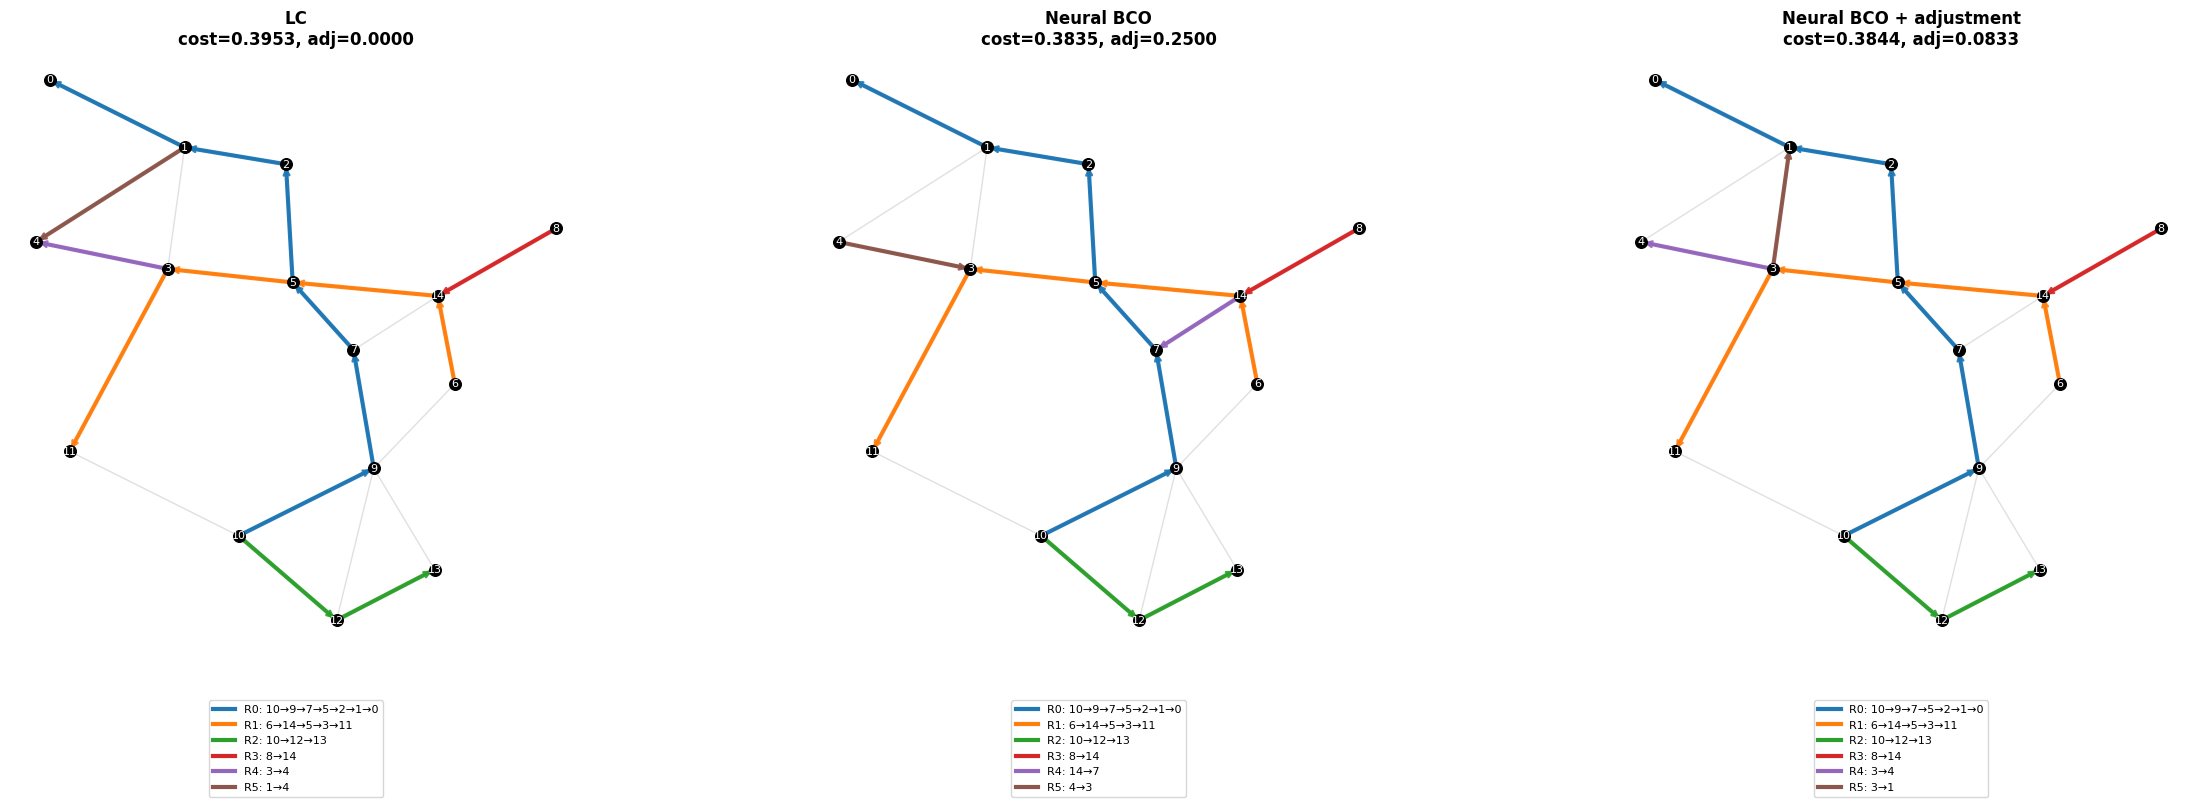

In [ ]:
import matplotlib.pyplot as plt


def get_first_route_set(routes):
    routes = as_route_tensor(routes)
    if routes.ndim == 3:
        return routes[0]
    return routes


def plot_route_set(ax, routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    n_nodes = coords.shape[0]

    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
                ax.plot(
                    [coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.7,
                    zorder=1,
                )

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, routes.shape[0])))
    handles = []
    for idx, route_tensor in enumerate(routes):
        route = [int(x) for x in route_tensor.tolist() if x != -1]
        if len(route) < 2:
            continue

        color = colors[idx % len(colors)]
        xs = coords[route, 0]
        ys = coords[route, 1]
        ax.plot(xs, ys, color=color, linewidth=3.0, alpha=0.95, zorder=3)

        for k in range(len(route) - 1):
            u = route[k]
            v = route[k + 1]
            ax.annotate(
                "",
                xy=(coords[v, 0], coords[v, 1]),
                xytext=(coords[u, 0], coords[u, 1]),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.8, alpha=0.9),
                zorder=4,
            )

        route_label = " -> ".join(map(str, route))
        if len(route_label) > 28:
            route_label = route_label[:25] + "..."
        handles.append(
            plt.Line2D([0], [0], color=color, lw=3, label=f"R{idx}: {route_label}")
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=70, zorder=5)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(
            x,
            y,
            str(node_idx),
            fontsize=8,
            color="white",
            ha="center",
            va="center",
            zorder=6,
        )

    if subtitle is not None:
        ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight="bold")
    else:
        ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")
    if handles:
        ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.08), fontsize=8, frameon=True)


coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]

route_sets = [
    (
        "LC",
        routes_lc,
        f"cost={_val(metrics_lc, 'cost'):.4f}, cur=0.0000, paper=0.0000",
    ),
    (
        "Neural BCO",
        routes_bco,
        f"cost={_val(metrics_bco, 'cost'):.4f}, cur={bco_adjustment_current:.4f}, paper={bco_adjustment_paper:.4f}",
    ),
    (
        "Neural BCO + current adjustment",
        routes_bco_current,
        f"cost={_val(metrics_bco_current, 'cost'):.4f}, cur={bco_current_adjustment_current:.4f}, paper={bco_current_adjustment_paper:.4f}",
    ),
    (
        "Neural BCO + paper adjustment",
        routes_bco_paper,
        f"cost={_val(metrics_bco_paper, 'cost'):.4f}, cur={bco_paper_adjustment_current:.4f}, paper={bco_paper_adjustment_paper:.4f}",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(24, 16), constrained_layout=True)
for ax, (title, routes, subtitle) in zip(axes.flat, route_sets):
    plot_route_set(ax, routes, coords, street_adj, title, subtitle)

plt.show()
